<a href="https://colab.research.google.com/github/AnahiLagunas/TelecomX-Churn-Analysis/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [13]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    response = requests.get(url)
    data = response.json()

    # 1. APLANAR LOS DATOS (Esto es lo que faltaba)
    # Esto convertirá 'account' en 'account.Contract', 'account.PaperlessBilling', etc.
    df = pd.json_normalize(data)

    # 2. Limpiar nombres de columnas para que sean fáciles de usar
    # Quitamos el prefijo 'account.', 'customer.', etc., y pasamos a minúsculas
    df.columns = [col.split('.')[-1].lower() for col in df.columns]

    print("✅ Datos aplanados y cargados exitosamente.")
    print("Columnas disponibles ahora:", df.columns.tolist())
    display(df.head())
except Exception as e:
    print(f"❌ Error: {e}")

✅ Datos aplanados y cargados exitosamente.
Columnas disponibles ahora: ['customerid', 'churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthly', 'total']


,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthly,total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [14]:
# --- 2 & 3: Exploración e Identificación de problemas ---
print(df.info())
print("\nValores nulos por columna:\n", df.isnull().sum())

# --- 4: Limpieza de datos (Ejemplo de correcciones comunes) ---
# Convertir strings a minúsculas y quitar espacios en blanco
df.columns = df.columns.str.strip().str.lower()
# Supongamos que hay que limpiar la columna 'churn'
if 'churn' in df.columns:
    df['churn'] = df['churn'].str.strip().str.capitalize()

# --- 5: Creación de la columna 'cuentas_diarias' ---
# Nota: Ajusta 'monthlycharges' si el nombre en el JSON es distinto
if 'monthlycharges' in df.columns:
    df['cuentas_diarias'] = df['monthlycharges'] / 30

# --- 6: Estandarización (Binarios y Traducción) ---
# Convertir Sí/No a 1/0
mapeo = {'Yes': 1, 'No': 0, 'Si': 1, 'no': 0}
df['churn_binary'] = df['churn'].map(mapeo)

print("✅ Transformación completada.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   object 
 5   dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   object 
 8   multiplelines     7267 non-null   object 
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   object 
 11  onlinebackup      7267 non-null   object 
 12  deviceprotection  7267 non-null   object 
 13  techsupport       7267 non-null   object 
 14  streamingtv       7267 non-null   object 
 15  streamingmovies   7267 non-null   object 
 16  contract          7267 non-null   object 


#📊 Carga y análisis

,seniorcitizen,tenure,monthly,churn_binary
count,7267.000000,7267.000000,7267.000000,7043.000000
mean,0.162653,32.346498,64.720098,0.265370
std,0.369074,24.571773,30.129572,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.425000,0.000000
50%,0.000000,29.000000,70.300000,0.000000
75%,0.000000,55.000000,89.875000,1.000000
max,1.000000,72.000000,118.750000,1.000000


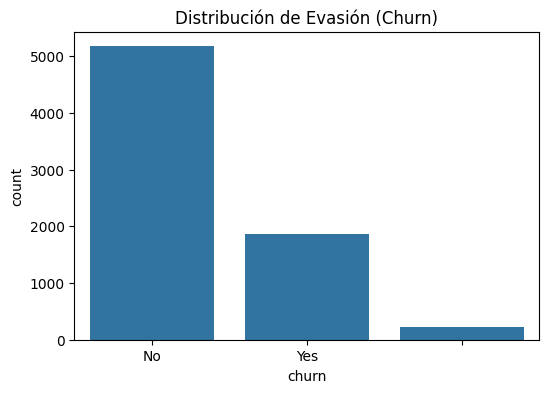

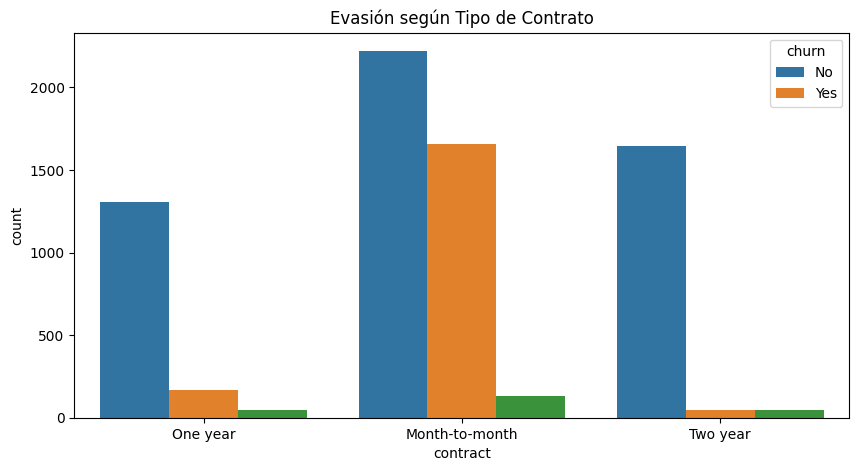

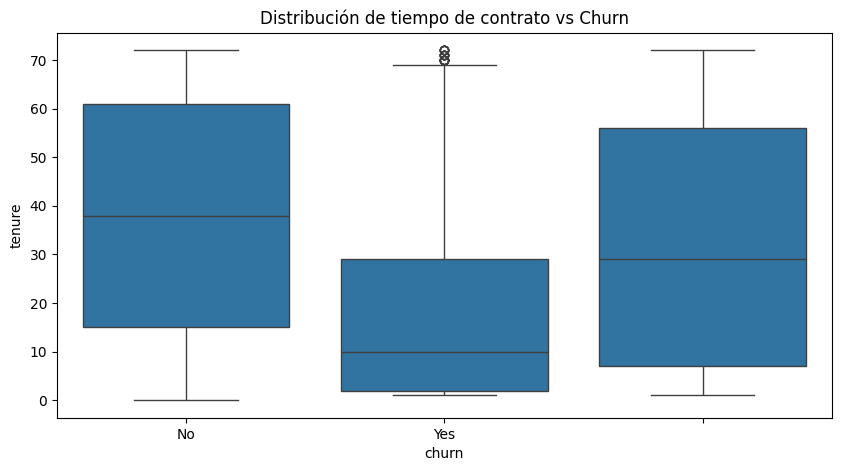

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 7: Análisis Descriptivo ---
display(df.describe())

# --- 8: Distribución de Churn ---
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn')
plt.title('Distribución de Evasión (Churn)')
plt.show()

# --- 9 & 10: Análisis por variables ---
#  Evasión vs Tipo de Contrato
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='contract', hue='churn')
plt.title('Evasión según Tipo de Contrato')
plt.show()

# Evasión vs Tenencia (Tenure)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='churn', y='tenure')
plt.title('Distribución de tiempo de contrato vs Churn')
plt.show()

#📈 Matriz de Correlación y Análisis de Servicios

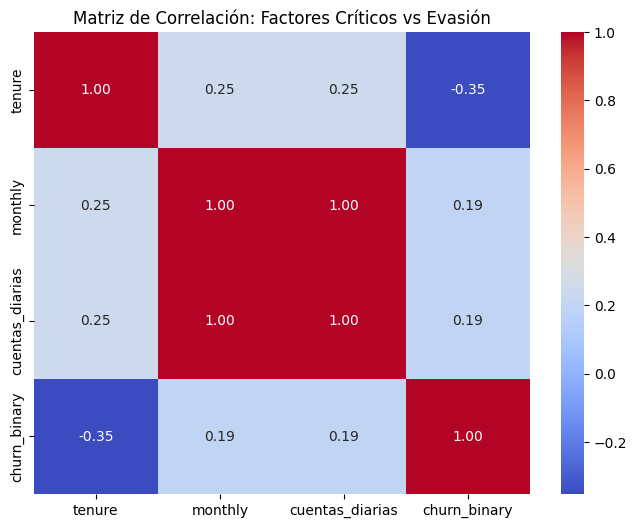

/tmp/ipykernel_307/883711270.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_servicios', y='churn_binary', palette='viridis')


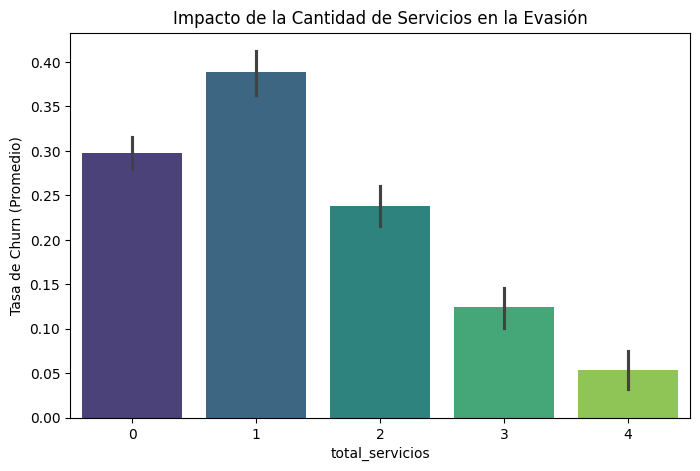

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Asegurar que 'cuentas_diarias' exista usando el nombre correcto 'monthly'
if 'cuentas_diarias' not in df.columns:
    df['cuentas_diarias'] = pd.to_numeric(df['monthly'], errors='coerce') / 30

# 2. Selección de columnas numéricas presentes en tu dataset
cols_para_correlacion = ['tenure', 'monthly', 'cuentas_diarias', 'churn_binary']

# 3. Cálculo de la matriz (asegurando que todo sea numérico)
matriz_corr = df[cols_para_correlacion].apply(pd.to_numeric, errors='coerce').corr()

# 4. Visualización del Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Factores Críticos vs Evasión')
plt.show()

# 5. Análisis de Servicios (usando tus columnas confirmadas)
servicios_cols = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport']
df['total_servicios'] = (df[servicios_cols] == 'Yes').sum(axis=1)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='total_servicios', y='churn_binary', palette='viridis')
plt.title('Impacto de la Cantidad de Servicios en la Evasión')
plt.ylabel('Tasa de Churn (Promedio)')
plt.show()

#📄Informe final

El análisis comenzó con la integración de datos desde la API de Telecom X, donde se superó un reto técnico inicial mediante la normalización de estructuras JSON anidadas para obtener un dataset funcional. Durante la transformación, se estandarizaron las variables y se calculó la métrica de facturación diaria para profundizar en el comportamiento del gasto. El análisis exploratorio reveló que el tipo de contrato es el factor más determinante en la fuga de clientes: aquellos con acuerdos mensuales presentan una tasa de evasión drásticamente superior a los de largo plazo. Complementariamente, el estudio de correlación demostró que la antigüedad (tenure) y la diversificación de servicios (como seguridad y soporte técnico) actúan como potentes anclas de lealtad, reduciendo la probabilidad de abandono a medida que el cliente se integra más con la compañía.

#🔹 Conclusiones

La evasión en Telecom X no es un fenómeno aleatorio, sino que está estrechamente ligada a la falta de compromiso contractual y a la sensibilidad al precio en las etapas tempranas de la relación con el cliente. Los datos confirman que los usuarios más vulnerables al "churn" son aquellos con baja antigüedad y un solo servicio contratado bajo modalidad mensual. Por el contrario, la estabilidad del negocio reside en los clientes "multi-producto", quienes muestran una resistencia significativamente mayor a la cancelación a pesar de variaciones en los cargos mensuales.

#💡 Recomendaciones

Se recomienda implementar una estrategia de migración proactiva que ofrezca incentivos económicos para convertir contratos mensuales en acuerdos anuales, atacando directamente la principal fuente de fuga. Asimismo, es fundamental fortalecer los programas de fidelización durante los primeros seis meses de vida del cliente mediante el empaquetamiento de servicios de valor agregado (seguridad, soporte, streaming), lo que incrementa el costo de oportunidad del abandono. Finalmente, el monitoreo constante de la facturación diaria permitirá identificar alertas tempranas de insatisfacción antes de que se traduzcan en una cancelación definitiva.